<div style="position: relative; background: linear-gradient(135deg, #24398A 0%, #1a2a66 100%); border-radius: 20px 20px 0px 0px; padding: 30px;  box-shadow: 0 8px 16px rgba(36, 57, 138, 0.3);">
  
  
  <div style="position: absolute; top: 20px; right: 20px; background: white; padding: 4px; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.2);">
    <img src="images/logo_unison.jpg" alt="UNISON" style="height: 160px;">
  </div>
  
  
  <div style="position: absolute; top: 20px; left: 20px; background: white; padding: 4px; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.2);">
    <img src="images/genetic_banner.jpg" alt="Curso" style="height: 160px;">
  </div>
   
  
  <div style="color: white; max-width: 60%; margin: 0 auto; text-align: center;">
    <h1 style="color: #EBA93B; margin: 0; font-size: 28px; text-shadow: 2px 2px 4px rgba(0,0,0,0.3);">
      Metaheurísticas para Ciencia de Datos: <br>Teoría y Práctica
    </h1><br>
    <h3 style="margin: 15px 0 5px 0; font-size: 16px; opacity: 0.95;">Maestría en Ciencia de Datos</br></br>
    Ramón Soto C. / ramon.soto@unison.mx</h3>
  </div>
</div>

<div style="background: white; border: 3px solid #EBA93B; border-radius: 0px 0px 20px 20px; padding: 25px;">
  <div style="display: flex; align-items: center; margin-bottom: 15px;">
    <div style="background: #24398A; color: white; font-size: 24px; font-weight: bold; padding: 10px 20px; border-radius: 8px; margin-right: 20px;">02</div>
    <div>
      <h2 style="color: #24398A; margin: 0;">Sistemas complejos y la naturaleza de las series de tiempo</h2>
      <p style="color: #666; margin: 5px 0 0 0; font-style: italic;">Una mirada al mundo real, más allá de las funciones lisas y los modelos dóciles</p>
    </div>
  </div>
  
  <div style="background: #f8f9fa; padding: 15px; border-radius: 5px; border-left: 4px solid #24398A;">
    <h4><strong>Presentación general:</strong></h4>
    <p>La ciencia de datos tradicional asume mundos lineales y estacionarios. Pero ¿qué ocurre cuando los datos provienen de sistemas dinámicos no lineales, caóticos o con propiedades emergentes? 
        </p>
      <p >
        En dominios como los mercados financieros o la dinámica atmosférica, no existe una dinámica estable que permita modelar el sistema mediante la reducción a sus componentes individuales. Los <b>sistemas complejos</b> se caracterizan por la emergencia de patrones globales a partir de interacciones locales simples. Para el científico de datos, esto implica reconocer que la linealidad es una excepción y que el verdadero reto reside en capturar la auto-organización y la sensibilidad a condiciones iniciales que definen el comportamiento de los datos en entornos reales.
    </p>
  </div>
</div>


<div style="
  background: #fdf8e3;
  border-left: 6px solid #d39e00;
  padding: 20px 25px;
  margin: 30px 0;
  border-radius: 8px;
  font-style: italic;
  color: #5a4a00;
  box-shadow: 0 4px 8px rgba(0,0,0,0.05);
">
  <p style="margin: 0; font-size: 16px; line-height: 1.6;">
    “As far as the laws of mathematics refer to reality, they are not certain,
    and as far as they are certain, they do not refer to reality.”
  </p>
  <p style="margin: 10px 0 0 0; text-align: right; font-weight: bold;">
    — Albert Einstein
  </p>
</div>



In [1]:
# CONFIGURACIÓN INICIAL
# =====================

# Librerías numéricas y científicas básicas
import numpy as np
import pandas as pd
import math

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Series de tiempo y dinámica (se usarán progresivamente)
from scipy.integrate import odeint
import scipy.stats as stats

# Análisis no lineal y datos reales
import nolds
import yfinance as yf

# ---------------------
# Configuración estética
# ---------------------
np.set_printoptions(precision=4, suppress=True)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

# Reproducibilidad
np.random.seed(42)

print("Entorno inicial listo.")


Entorno inicial listo.


## 1. Del lenguaje combinatorio al dominio temporal

Los problemas de optimización son un **lenguaje formal** para expresar la búsqueda de soluciones en espacios complejos. Las metaheurísticas surgieron como respuesta a problemas combinatorios NP-duros (TSP, scheduling, knapsack), donde la enumeración exhaustiva es computacionalmente intratable.

Pero su utilidad trasciende lo combinatorio.

Cualquier problema que pueda expresarse como:

$$\text{Encontrar } \theta^* = \arg\min_{\theta \in \Theta} f(\theta)$$

donde $f(\theta)$ sea **costosa de evaluar**, tenga **múltiples óptimos locales** o carezca de **estructura diferenciable**, es candidato natural para metaheurísticas.

Y eso incluye un dominio fundamental en ciencia de datos: **las series de tiempo**.

### Series de tiempo: más allá de la predicción estadística

Una **serie de tiempo** es el registro de la huella dejada por un sistema dinámico a través de una única variable observada a intervalos regulares (o irregulares) en el tiempo. Es como tomar "fotografías" sucesivas de una sola característica del sistema conforme evoluciona. Por ejemplo, el precio diario dólar contra el peso (sistema financiero) o la temperatura diaria (sistema atmosférico).

Tradicionalmente, las series de tiempo se abordan mediante modelos paramétricos (como ARIMA o GARCH) o, más recientemente, mediante arquitecturas de aprendizaje profundo (principalmente LSTM, Transformers). Estos enfoques asumen que:

- Existe una forma funcional razonable (lineal, log-lineal, recurrente)
- Los parámetros pueden estimarse por máxima verosimilitud y descenso de gradiente
- Se mantienen propiedades estadísticas como estacionariedad y ergodicidad

Pero cuando trabajamos con **series complejas**—generadas por sistemas caóticos, multiescala o con cambios de régimen—estos supuestos fallan:

| **Aspecto** | **Enfoque Clásico** | **Realidad en Series Complejas** |
|-------------|---------------------|----------------------------------|
| **Forma funcional** | Conocida (AR, MA) | Desconocida, posiblemente no paramétrica |
| **Parámetros** | Pocos, estimables por MLE | Muchos, interdependientes, multimodales |
| **Horizonte de predicción** | Asintóticamente estable | Limitado por exponente de Lyapunov |
| **Estacionariedad** | Asumida o transformable | Violada estructuralmente (bifurcaciones) |
| **Optimización** | Convexa (o casi) | No convexa, discontinua, ruidosa |

En estos escenarios, las metaheurísticas no son una alternativa—son **la herramienta natural**.

## 2. La complejidad como condición natural del mundo

Cuando hablamos de ciencia de datos, solemos imaginar modelos aplicados a conjuntos ordenados de información, donde los fenómenos siguen patrones discernibles, regularidades estables y estructuras razonablemente predecibles. Pero el mundo real rara vez se comporta así.

Gran parte de los fenómenos que estudiamos en economía, biología, física, energía, clima, neurología y sistemas sociales **no son lineales ni estacionarios**. Son sistemas donde millones de microsucesos interactúan constantemente, dando lugar a comportamientos globales que no pueden deducirse de sus partes.

A esa familia de fenómenos la llamamos **sistemas complejos**.

<br>
<p align="center">
  <img src="images/chaos.gif" width="600">
</p>


---

## 2. Fundamentos teóricos

### ¿Qué es un sistema complejo?

Un sistema complejo no es simplemente un sistema "complicado". Es un sistema donde:

* **Múltiples componentes interactúan localmente** (sin coordinador central)
* **Pequeñas variaciones dan lugar a grandes efectos** (sensibilidad a condiciones iniciales - **efecto mariposa**)
* **Estructuras globales emergen** sin diseño explícito (**emergencia**)
* **Comportamiento multimodal** (estable o caótico según contexto)
* **El ruido puede ser funcional**, no error de medición
* **Los modelos clásicos fallan** (lineales, gaussianos, estacionarios)

| Aspecto | Sistema Complicado | Sistema Complejo |
| :--- | :--- | :--- |
| Ejemplo | Motor de avión | Ecosistema, cerebro |
| Componentes | Muchos, pero independientes | Muchos, altamente acoplados e interdependientes |
| Comportamiento | Predecible dadas las partes | Emergente, no deducible |
| Análisis | Reduccionismo funciona | Reduccionismo falla |
| Causalidad | Lineal, trazable | No lineal, circular |
| Ruido | Error de medición | Parte funcional del sistema |
| Modelado | Ingeniería clásica | Teoría de sistemas dinámicos |

**Ejemplos Paradigmáticos**

* **Sistemas Físicos:** Clima global, Turbulencia en fluidos, Redes eléctricas
* **Sistemas Biológicos:** El cerebro (86 mil millones de neuronas), El corazón (arritmias), Redes de regulación genética
* **Sistemas Socio-Económicos:** Mercados financieros, Tráfico vehicular urbano, Pandemias (COVID-19)

**Característica común:** Son impredecibles en detalle, pero predecibles en estructura (atractores, patrones estadísticos).

### Propiedades emergentes: El todo es más que la suma

Una propiedad **emergente** es un comportamiento del sistema completo que no existe en ningún componente individual. 1 neurona tan sólo dispara o no dispara (~0/1); 86 mil millones de neuronas interactuando dan origen a la memoria, el lenguaje, la creatividad. **La complejidad no escala linealmente**




### Ejemplo simple: El Juego de la Vida de Conway

El **Juego de la Vida** (Conway's Game of Life) es un autómata celular inventado por el matemático John Conway en 1970. A pesar de su nombre, no es un "juego" en el sentido tradicional: no hay jugadores, no hay ganadores, no hay objetivos. Es un **universo artificial** que evoluciona según reglas matemáticas extremadamente simples.

<br>
<p align="center">
  <img src="images/3d-game-of-life.png" width="300">
</p>

### Universo: Una cuadrícula infinita

- Imaginemos una cuadrícula bidimensional infinita (como un tablero de ajedrez sin fin)
- Cada celda puede estar en uno de dos estados: **viva** (■) o **muerta** (□)
- El tiempo avanza en pasos discretos llamados **generaciones**
- En cada generación, TODAS las celdas se actualizan simultáneamente según sus vecinos

### Reglas: Asombrosamente simples

Cada celda tiene **8 vecinos** (arriba, abajo, izquierda, derecha y las 4 diagonales). El destino de cada celda depende únicamente de cuántos vecinos vivos tiene:

1. **Una célula viva con 2-3 vecinos → sobrevive**
- **Supervivencia:** Si tiene 2 o 3 vecinos vivos → sobrevive
- **Muerte por soledad:** Si tiene 0 o 1 vecinos → muere
- **Muerte por sobrepoblación:** Si tiene 4+ vecinos → muere

2. **Una célula muerta con 3 vecinos vivos → nace**
- **Nacimiento:** Si tiene exactamente 3 vecinos vivos → nace (revive)
- **Permanece muerta:** En cualquier otro caso

No hay aleatoriedad, no hay excepciones, no hay casos especiales. El comportamiento futuro del sistema está **completamente determinado** por su configuración inicial.


Inicializando con configuración ALEATORIA (30% células vivas)...



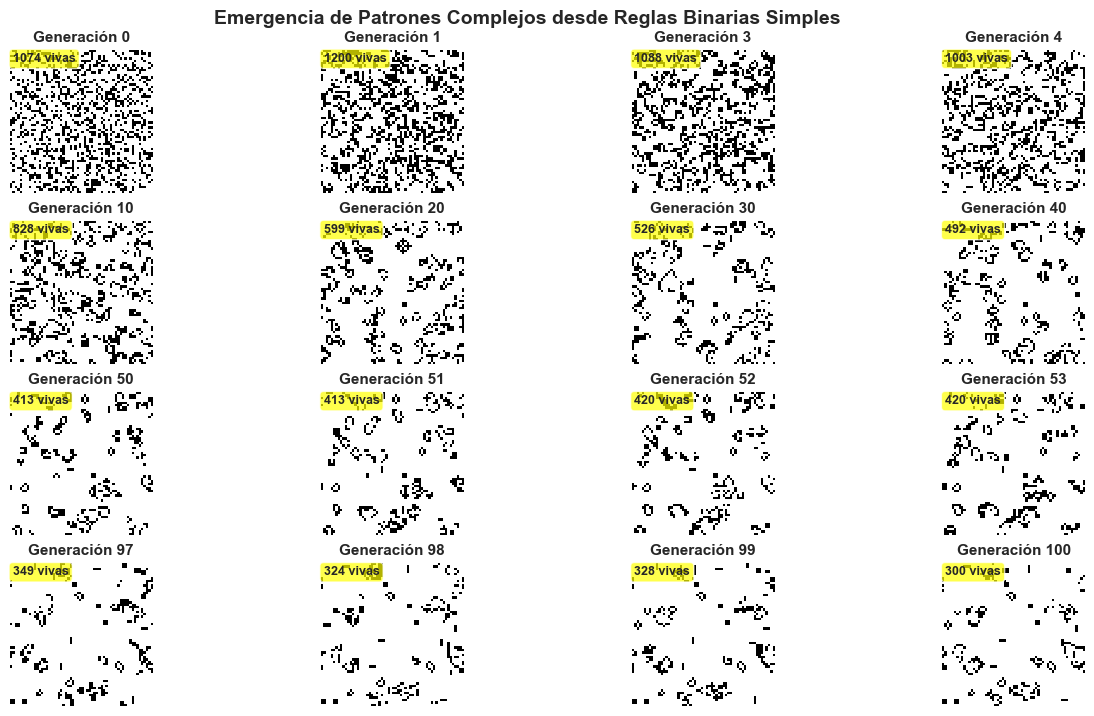

In [2]:
# Juego de la Vida de Conway - Emergencia más simple

from matplotlib.colors import ListedColormap

class GameOfLife:
    
    def __init__(self, size=50):
        self.size = size
        # Inicializar grid aleatorio
        self.grid = np.random.choice([0, 1], size=(size, size), p=[0.7, 0.3])
    
    def count_neighbors(self):
        """Contar vecinos vivos de cada célula (8 vecinos)"""
        neighbors = np.zeros_like(self.grid)
        for i in range(-1, 2):
            for j in range(-1, 2):
                if i == 0 and j == 0:
                    continue
                neighbors += np.roll(np.roll(self.grid, i, axis=0), j, axis=1)
        return neighbors
    
    def step(self):
        """Un paso de evolución: aplicar las 2 reglas simples"""
        neighbors = self.count_neighbors()
        
        # Regla 1: Supervivencia (2-3 vecinos)
        survive = (self.grid == 1) & ((neighbors == 2) | (neighbors == 3))
        
        # Regla 2: Nacimiento (exactamente 3 vecinos)
        birth = (self.grid == 0) & (neighbors == 3)
        
        # Nuevo estado
        self.grid = (survive | birth).astype(int)


# Crear simulación
print("Inicializando con configuración ALEATORIA (30% células vivas)...\n")
game = GameOfLife(size=60)

# Visualizar evolución
fig, axes = plt.subplots(4, 4, figsize=(16, 8))
axes = axes.flatten()

cmap = ListedColormap(['white', 'black'])
times = [0, 1, 3, 4, 10, 20, 30, 40, 50, 51, 52, 53, 97, 98, 99, 100]      # Generaciónes a desplegar

for idx, t in enumerate(times):
    # Avanzar simulación
    if idx > 0:
        steps = times[idx] - times[idx-1]
        for _ in range(steps):
            game.step()
    
    # Graficar
    axes[idx].imshow(game.grid, cmap=cmap, interpolation='nearest')
    axes[idx].set_title(f'Generación {t}', fontweight='bold', fontsize=11)
    axes[idx].axis('off')
    
    # Anotar número de células vivas
    n_alive = game.grid.sum()
    axes[idx].text(0.02, 0.98, f'{n_alive} vivas', 
                   transform=axes[idx].transAxes,
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7),
                   fontsize=9, fontweight='bold')

plt.suptitle('Emergencia de Patrones Complejos desde Reglas Binarias Simples', 
             fontsize=14, fontweight='bold')
plt.subplots_adjust(wspace=0.01, hspace=0.2, top=0.93) 
plt.show()


#### Conclusiones del Juego de la Vida: Lecciones para sistemas complejos

Partimos de una **configuración completamente aleatoria** (30% de células vivas) y aplicamos **solo 2 reglas deterministas**. El resultado es el siguiente:

* **Gen 0-4:** Caos inicial se reorganiza localmente
* **Gen 10-40:** Emergen estructuras estables (
* **Gen 50+:** El sistema alcanza un estado cuasi-estable con osciladores periódicos
* **Gen 100:** Patrón complejo auto-organizado que nunca fue "diseñado"

---

### Características de sistemas complejos presentes

| Característica | Manifestación en el Juego de la Vida |
|:--------------|:------------------------------------|
| **Interacciones locales** | Cada célula solo "conoce" a sus 8 vecinos |
| **Emergencia** | Patrones globales que ninguna célula individual contiene |
| **Auto-organización** | Orden emerge del caos sin control central |
| **Determinismo caótico** | Reglas simples → comportamiento impredecible en detalle |
| **Sensibilidad a condiciones iniciales** | Cambiar 1 célula inicial puede alterar completamente la evolución |

---


## 3. La firma matemática: Caos, atractores y sensibilidad

Los sistemas complejos suelen presentar **caos determinista**.

**Caos determinista NO significa:**
- Comportamiento aleatorio
- Falta de ecuaciones
- Impredecibilidad absoluta

**Caos determinista SÍ significa:**
- Dinámicas gobernadas por **ecuaciones exactas y deterministas**
- Que producen comportamientos **aparentemente aleatorios**
- **Sensibilidad extrema** a condiciones iniciales (efecto mariposa)
- **Predecibles a corto plazo**, impredecibles a largo plazo


### El atractor extraño de Lorenz: El icono del caos

Edward Lorenz (1963) descubrió el caos determinista al simplificar las ecuaciones de convección atmosférica. Buscaba predecir el clima y encontró que era fundamentalmente impredecible a largo plazo.

**Sistema de ecuaciones diferenciales:**

$$
\begin{aligned}
\frac{dx}{dt} &= \sigma(y - x) \quad &&\text{(transferencia de calor)} \\
\frac{dy}{dt} &= x(\rho - z) - y \quad &&\text{(diferencia de temperatura horizontal)} \\
\frac{dz}{dt} &= xy - \beta z \quad &&\text{(diferencia de temperatura vertical)}
\end{aligned}
$$

**Parámetros típicos:** $\sigma = 10$ (número de Prandtl), $\rho = 28$ (número de Rayleigh), $\beta = 8/3$ (aspecto geométrico)

**Variables:**
- $x$: tasa de rotación del fluido
- $y$: diferencia de temperatura entre corrientes ascendentes y descendentes
- $z$: desviación del perfil de temperatura lineal

---

### Propiedades del atractor de Lorenz

| Propiedad | Descripción | Implicación |
|:----------|:------------|:------------|
| **Sensibilidad a condiciones iniciales** | Dos trayectorias inicialmente cercanas divergen exponencialmente | Error inicial de 0.000001 → impredecibilidad en ~20 pasos |
| **Atractor extraño** | Forma de "mariposa" en 3D con estructura fractal | Dimensión no entera (~2.06, entre superficie y volumen) |
| **No periódico** | La trayectoria nunca se repite exactamente | No hay ciclos, pero sí patrones estadísticos |
| **Determinista** | Mismas condiciones iniciales → misma trayectoria | Completamente reproducible, nada aleatorio |
| **Disipativo** | El volumen en el espacio de fase se contrae | Todas las trayectorias convergen al atractor |
| **Topológicamente mezclados** | Regiones cercanas se separan y distantes se juntan | Mezcla eficiente, como batir un líquido |


In [3]:
import matplotlib.cm as cm

# ============================================================================
# 0. CONFIGURACIÓN INICIAL - PARÁMETROS Y SISTEMA
# ============================================================================
def lorenz_system(state, t, sigma, rho, beta):
    """
    Sistema de Lorenz: modelo simplificado de convección atmosférica
    que exhibe comportamiento caótico.
    """
    x, y, z = state              # Desempaquetar el estado en las tres variables
    dxdt = sigma * (y - x)       # Tasa de cambio en x (la derivada)
    dydt = x * (rho - z) - y     # Tasa de cambio en y
    dzdt = x * y - beta * z      # Tasa de cambio en z
    return [dxdt, dydt, dzdt]

# Parámetros clásicos para régimen caótico (valores históricos de Lorenz, 1963)
sigma = 10.0      # Número de Prandtl (relación entre viscosidad y difusividad térmica)
rho = 28.0        # Número de Rayleigh (controla la inestabilidad convectiva)
beta = 8.0 / 3.0  # Parámetro geométrico relacionado con la relación de aspecto

# Condiciones iniciales - ¡DEMOSTRACIÓN DEL EFECTO MARIPOSA!
# Dos estados iniciales casi idénticos divergen exponencialmente en sistemas caóticos
initial_state_1 = [0.0, 1.0, 1.05]
initial_state_2 = [0.0, 1.0, 1.05 + 1e-3]  # Perturbación infinitesimal en z

# Tiempo de simulación: vector de 10000 puntos equiespaciados entre 0 y 40 unidades de tiempo
t = np.linspace(0, 40, 10000)  # Genera un arreglo de tiempos para la integración

# Variables para mostrar información (solo para visualización en el print)
x1, y1, z1 = initial_state_1
x2, y2, z2 = initial_state_2

print("SISTEMA DE LORENZ")
print(f"Parámetros del caos: σ={sigma}, ρ={rho}, β={beta:.4f}")
print(f"\nCondición inicial 1: [x={x1}, y={y1}, z={z1}]")
print(f"Condición inicial 2: [x={x2}, y={y2}, z={z2}]")
print(f"Diferencia inicial: Δz = {z2 - z1:.2e} (perturbación mínima)")
print("="*70)

# Integración numérica de las ecuaciones diferenciales
# odeint resuelve sistemas de EDOs usando métodos numéricos (por defecto: Adams/BDF)
trajectory_1 = odeint(lorenz_system, initial_state_1, t, args=(sigma, rho, beta))
trajectory_2 = odeint(lorenz_system, initial_state_2, t, args=(sigma, rho, beta))


SISTEMA DE LORENZ
Parámetros del caos: σ=10.0, ρ=28.0, β=2.6667

Condición inicial 1: [x=0.0, y=1.0, z=1.05]
Condición inicial 2: [x=0.0, y=1.0, z=1.051]
Diferencia inicial: Δz = 1.00e-03 (perturbación mínima)


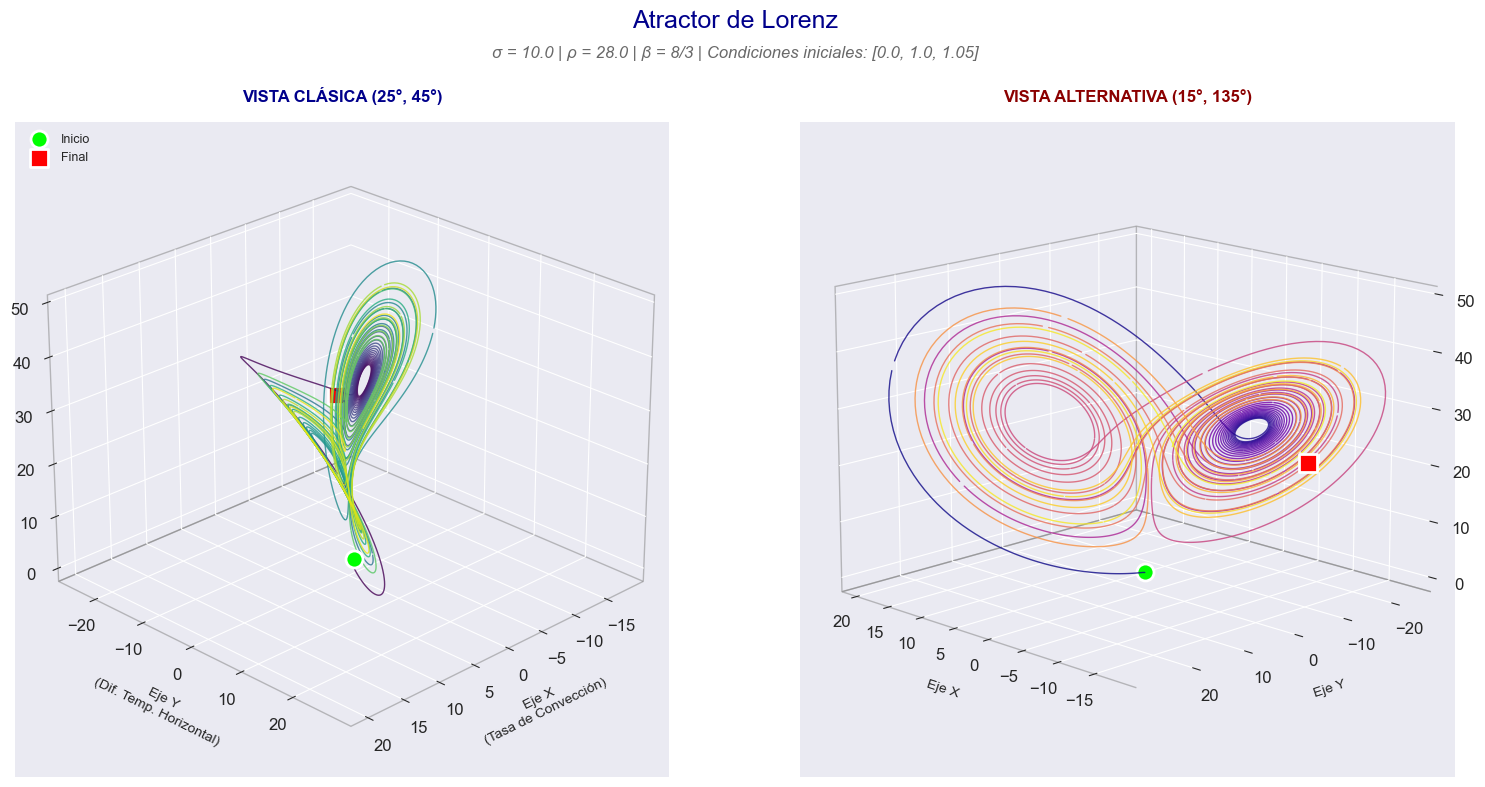

In [4]:
# ============================================================================
# 1. FIGURA PRINCIPAL: DOS VISTAS 3D DEL ATRACTOR
# ============================================================================

# Estilo visual: uso de seaborn-darkgrid para mejor contraste
plt.style.use('seaborn-v0_8-darkgrid')

fig = plt.figure(figsize=(16, 8))

# TÍTULO COMÚN PARA AMBAS GRÁFICAS
fig.suptitle('Atractor de Lorenz', fontsize=18, color='darkblue', y=1.05)

# Subtítulo con parámetros específicos (position 0.5, 0.99 relativo a la figura)
fig.text(0.5, 0.99, 
         'σ = 10.0 | ρ = 28.0 | β = 8/3 | Condiciones iniciales: [0.0, 1.0, 1.05]', 
         ha='center', fontsize=12, color='dimgray', style='italic')

# Paleta de colores para evolución temporal: cm.viridis crea gradiente continuo
# np.linspace genera 10000 valores entre 0 y 1 para mapear al colormap
colors = cm.viridis(np.linspace(0, 1, len(trajectory_1)))

# 1.1. VISTA 3D PRINCIPAL - ÁNGULO CLÁSICO
# Crear primer subplot en grid 1x2, posición 1, con proyección 3D
ax1 = fig.add_subplot(121, projection='3d')

# Dibujar trayectoria segmentada para gradiente de color temporal
# Se divide en segmentos de 100 puntos para aplicar colores diferentes
# El color representa el tiempo (inicio: azul oscuro, fin: amarillo)
for i in range(0, len(trajectory_1)-100, 100):
    ax1.plot(trajectory_1[i:i+100, 0],  # Coordenadas X del segmento
             trajectory_1[i:i+100, 1],  # Coordenadas Y del segmento
             trajectory_1[i:i+100, 2],  # Coordenadas Z del segmento
             color=colors[i], alpha=0.8, lw=1.0)  # Transparencia y grosor

# Marcar punto inicial con marcador circular verde
ax1.scatter(*initial_state_1, color='lime', s=150, marker='o', 
           edgecolor='white', linewidth=2, label='Inicio', zorder=10)
           # zorder=10 asegura que los puntos queden sobre la trayectoria

# Marcar punto final con marcador cuadrado rojo
ax1.scatter(*trajectory_1[-1], color='red', s=150, marker='s', 
           edgecolor='white', linewidth=2, label='Final', zorder=10)

# Configurar título y etiquetas de ejes con información física
ax1.set_title("VISTA CLÁSICA (25°, 45°)", fontweight='bold', fontsize=12, 
              color='darkblue', pad=15)  # pad añade espacio sobre el título
ax1.set_xlabel("Eje X\n(Tasa de Convección)", fontsize=10, labelpad=10)
ax1.set_ylabel("Eje Y\n(Dif. Temp. Horizontal)", fontsize=10, labelpad=10)
ax1.set_zlabel("Eje Z\n(Dif. Temp. Vertical)", fontsize=10, labelpad=10)

# Configuración visual para mejor claridad
ax1.grid(True, alpha=0.3)  # Cuadrícula semitransparente
# Hacer paneles de ejes transparentes para no obstruir vista
ax1.xaxis.pane.fill = False
ax1.yaxis.pane.fill = False
ax1.zaxis.pane.fill = False
# Bordes de paneles en gris para referencia espacial
ax1.xaxis.pane.set_edgecolor('gray')
ax1.yaxis.pane.set_edgecolor('gray')
ax1.zaxis.pane.set_edgecolor('gray')

# Configurar ángulo de vista: elevación 25°, azimut 45° (vista estándar)
ax1.view_init(elev=25, azim=45)
ax1.legend(loc='upper left', fontsize=9, framealpha=0.9)  # Leyenda con fondo semitransparente

# 1.2. VISTA 3D ALTERNATIVA - PERSPECTIVA DIFERENTE
ax2 = fig.add_subplot(122, projection='3d')  # Segundo subplot, posición 2

# Colormap alternativo para variedad visual
colors2 = cm.plasma(np.linspace(0, 1, len(trajectory_1)))

# Dibujar misma trayectoria con diferente esquema de color
for i in range(0, len(trajectory_1)-100, 100):
    ax2.plot(trajectory_1[i:i+100, 0], 
             trajectory_1[i:i+100, 1], 
             trajectory_1[i:i+100, 2],
             color=colors2[i], alpha=0.8, lw=1.0)

# Puntos de inicio y fin (sin leyenda para evitar sobrecarga)
ax2.scatter(*initial_state_1, color='lime', s=150, marker='o', 
           edgecolor='white', linewidth=2, zorder=10)
ax2.scatter(*trajectory_1[-1], color='red', s=150, marker='s', 
           edgecolor='white', linewidth=2, zorder=10)

# Configurar segunda vista
ax2.set_title("VISTA ALTERNATIVA (15°, 135°)", fontweight='bold', 
              fontsize=12, color='darkred', pad=15)
ax2.set_xlabel("Eje X", fontsize=10, labelpad=10)
ax2.set_ylabel("Eje Y", fontsize=10, labelpad=10)
ax2.set_zlabel("Eje Z", fontsize=10, labelpad=10)

# Configuración visual idéntica a primera vista
ax2.grid(True, alpha=0.3)
ax2.xaxis.pane.fill = False
ax2.yaxis.pane.fill = False
ax2.zaxis.pane.fill = False
ax2.xaxis.pane.set_edgecolor('gray')
ax2.yaxis.pane.set_edgecolor('gray')
ax2.zaxis.pane.set_edgecolor('gray')

# Ángulo de vista diferente para apreciar otras dimensiones
ax2.view_init(elev=15, azim=135)

# Ajuste fino del layout: márgenes y espacio entre subplots
plt.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.95, 
                    wspace=0.2, hspace=0.2)

plt.show()

En estas gráficas podemos observar la estructura en forma de "mariposa" o "máscara" que emerge espontáneamente a partir de ecuaciones deterministas simples en el sistema de Lorenz. El sistema orbita alternativamente alrededor de dos puntos fijos (centros de las "alas"), creando un patrón que nunca se repite exactamente. A pesar del comportamiento impredecible, la trayectoria permanece confinada a una región específica del espacio.

El gradiente de color (azul→amarillo en izquierda, púrpura→amarillo en derecha) representa el tiempo transcurrido desde t=0 hasta t=40.

La *vista clásica (25°, 45°)*, enfatiza la simetría bilateral y la estructura característica que dio nombre al "efecto mariposa". La *vista alternativa (15°, 135°)*, revela la complejidad tridimensional y cómo la trayectoria se entrelaza consigo misma en el espacio.


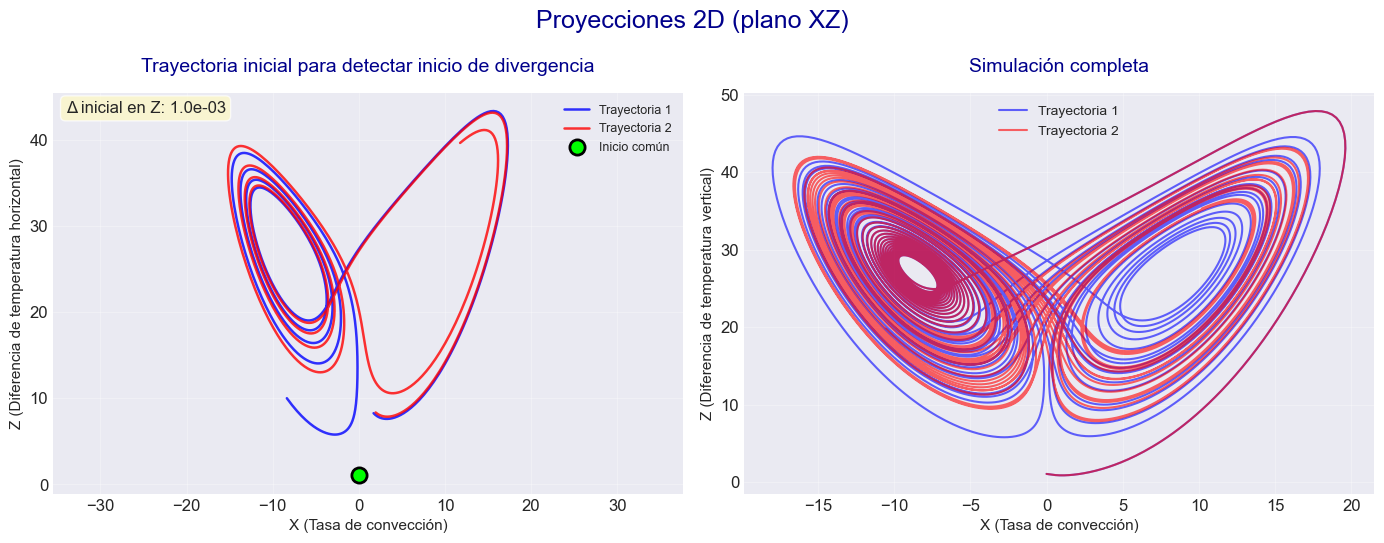

In [5]:
# ============================================================================
# 2. PROYECCIONES 2D: VISUALIZANDO EL EFECTO MARIPOSA
# ============================================================================

# Crear una nueva figura para las proyecciones 2D con 2 subgráficas horizontales
fig3, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Título común para las 2 proyecciones
fig3.suptitle('Proyecciones 2D (plano XZ)', fontsize=18, color='darkblue', 
              y=0.982)   # título cerca del borde superior

# Calcular distancia euclidiana entre trayectorias a lo largo del tiempo
# Esta métrica cuantifica la divergencia de las trayectorias
distance = np.sqrt(np.sum((trajectory_1 - trajectory_2)**2, axis=1))

# Encontrar índices donde la distancia supera el umbral
threshold = 0.5          # Umbral arbitrario para considerar "divergencia significativa"
cross_idx = np.where(distance > threshold)[0]

# Tiempo en que ocurre la primera divergencia significativa (si existe)
start_view = cross_idx[0] if len(cross_idx) > 0 else t[-1] # Punto donde la divergencia supera el umbral
cross_time = t[start_view] 

# ============================================================================
# 2.1. PROYECCIÓN XY (PRIMERAS 2000 UNIDADES DE TIEMPO)
# ============================================================================
end_view = start_view + 1000  # Punto final a graficar (para apreciar la divergencia)

# Graficar ambas trayectorias en plano XZ 
ax1.plot(trajectory_1[start_view:end_view, 0], trajectory_1[start_view:end_view, 2], 
         color='blue', alpha=0.8, lw=1.8, label='Trayectoria 1')
ax1.plot(trajectory_2[start_view:end_view, 0], trajectory_2[start_view:end_view, 2], 
         color='red', alpha=0.8, lw=1.8, label='Trayectoria 2')

# Marcador de inicio (punto inicial común a ambas trayectorias)
ax1.scatter(trajectory_1[0, 0], trajectory_1[0, 2], color='lime', s=120, marker='o', 
           edgecolors='black', linewidth=2, zorder=10, label='Inicio común')

# Configuración de título y etiquetas
ax1.set_title("Trayectoria inicial para detectar inicio de divergencia", 
              fontsize=14, color='darkblue', pad=15)
ax1.set_xlabel("X (Tasa de convección)", fontsize=11)
ax1.set_ylabel("Z (Diferencia de temperatura horizontal)", fontsize=11)
ax1.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax1.grid(True, alpha=0.3)
# Mantener proporción 1:1 para visualización precisa de trayectorias
ax1.set_aspect('equal', adjustable='datalim')

# Anotación que muestra la perturbación inicial mínima en Z
ax1.annotate(f'Δ inicial en Z: {initial_state_2[2] - initial_state_1[2]:.1e}', 
             xy=(0.02, 0.95), xycoords='axes fraction',     # Posición relativa al eje
             fontsize=12, bbox=dict(boxstyle="round,pad=0.3", facecolor="#FEF9C2", alpha=0.7))

# ============================================================================
# 2.2. PROYECCIÓN XZ (COMPARACIÓN COMPLETA)
# ============================================================================
# Graficar trayectorias completas (10,000 puntos) en plano X-Z
ax2.plot(trajectory_1[:, 0], trajectory_1[:, 2], 
         color='blue', alpha=0.6, lw=1.5, label='Trayectoria 1')
ax2.plot(trajectory_2[:, 0], trajectory_2[:, 2], 
         color='red', alpha=0.6, lw=1.5, label='Trayectoria 2')

ax2.set_title("Simulación completa",  fontsize=14, color='darkblue', pad=15)
ax2.set_xlabel("X (Tasa de convección)", fontsize=11)
ax2.set_ylabel("Z (Diferencia de temperatura vertical)", fontsize=11)
ax2.legend(loc='upper center', fontsize=10, framealpha=0.9)
ax2.grid(True, alpha=0.3)

# Ajustar layout para evitar superposición (rect define [left, bottom, right, top])
plt.tight_layout(rect=[0, 0.08, 1, 1.0])

# Mostrar la figura
plt.show()


Ambas trayectorias (azul y roja) comienzan (prácticamente) en el mismo punto (marcador verde) si se hace start_view=0. Inicialmente las trayectorias son indistinguibles, pero poco a poco comienzan a separarse: La separación crece de manera **exponencial**, no lineal. Después de start_view (para el umbral dado), las trayectorias son completamente diferentes. 

Aunque los caminos específicos difieren, ambas exploran la misma región del espacio.

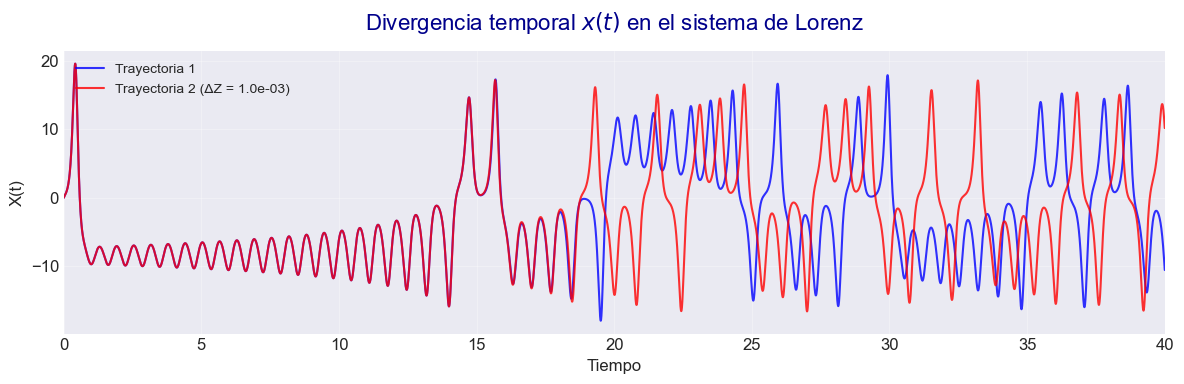

In [6]:
# ============================================================================
# 4. DIVERGENCIA TEMPORAL: EL EFECTO MARIPOSA EN X(t)
# ============================================================================

plt.figure(figsize=(12, 4))
plt.style.use('seaborn-v0_8-darkgrid')

# Graficar X(t) para ambas trayectorias en función del tiempo
plt.plot(t, trajectory_1[:, 0], label='Trayectoria 1', lw=1.5, color='blue', alpha=0.8)
plt.plot(t, trajectory_2[:, 0], 
         label=f'Trayectoria 2 (ΔZ = {initial_state_2[2] - initial_state_1[2]:.1e})', 
         lw=1.5, color='red', alpha=0.8)

plt.title('Divergencia temporal $x(t)$ en el sistema de Lorenz', fontsize=16, color='darkblue', pad=15)

# Etiquetas de ejes
plt.xlabel('Tiempo', fontsize=12)
plt.ylabel('X(t)', fontsize=12)

# Leyenda en esquina superior izquierda con fondo semitransparente
plt.legend(loc='upper left', fontsize=10, framealpha=0.9)

# Cuadrícula sutil para mejor lectura de valores
plt.grid(True, alpha=0.3)

# Ajustar límites del eje X para mostrar toda la simulación
plt.xlim([0, t[-1]])  # t[-1] es el último valor del array t (40 en este caso)

# Ajustar layout automáticamente para evitar cortes
plt.tight_layout()

# Mostrar la gráfica
plt.show()


Esta gráfica muestra la evolución temporal de la coordenada **X** (tasa de convección) para las dos trayectorias con condiciones iniciales ligeramente diferentes. Es la visualización más directa del **efecto mariposa**.

----

**Frase histórica de Lorenz (1972):**

> "Un aleteo de mariposa en Brasil puede causar un tornado en Texas."

**... y el antecedenta de Ray Bradbury (1963):**

> "*He looked at the soles of his shoes. Embedded in the mud, glistening green and gold and black, was a butterfly, very beautiful and very dead.*"


**... y Zitarrosa (1985):**
> "*... sino que era mariposa, nada más: en la ciudad, presa y ya muerta de antemano, fatalmente; buscando en ese bailar loco y frágil un ala, un grano, una pizca de polen en el cemento.*"

---

### Mackey–Glass y modelado de fenómenos biológicos

El sistema de Mackey–Glass (1977) se propuso para describir procesos fisiológicos con **retroalimentación retardada**, como la producción de células sanguíneas:

$$
\frac{dx}{dt} = \frac{\beta x(t-\tau)}{1 + x(t-\tau)^n} - \gamma x(t)
$$

<ul><li><b>Parámetros típicos:</b></li>
    <ul>
    <li>$\beta = 0.2$ (tasa de producción)</li>
    <li>$\gamma = 0.1$ (tasa de decaimiento)</li>
    <li>$n = 10$ (exponente no lineal)</li>
    <li>$\tau$ = retardo temporal (<b>parámetro crítico</b>)<br>Para $\tau > 16.8$, el sistema se vuelve caótico.</li>
    </ul>
</ul>

Originalmente fue propuesto por Michael Mackey y Leon Glass como un modelo con retardo para la regulación de la hematopoyesis (producción de células sanguíneas). La idea era capturar cómo los tiempos de maduración introducen retroalimentación diferida y pueden generar oscilaciones o inestabilidad.

Actualmente se sigue usando como modelo canónico de dinámica con retardo para ilustrar cómo los delays fisiológicos producen oscilaciones, multiestabilidad y caos. Este comportamiento hace de este sistema otro caso muy útil como sistema de prueba.

<ul><li><b>Fenómeno común:</b> Retroalimentación retardada aparece en:</li>
    <ul>
    <li>Regulación hormonal (insulina, cortisol)</li>
    <li>Dinámica poblacional (depredador-presa)</li>
    <li>Sistemas económicos (inflación, inversión)</li>
    </ul>
</ul>

<ul><li><b>Desafío técnico:</b> ARIMA, Exponential Smoothing y regresión lineal fallan completamente.</li>
</ul>


> Mackey-Glass no es solo una ecuación diferencial; es un gimnasio mental para diseñar algoritmos inteligentes que manejen complejidad temporal. Si una metaheurística puede navegar este sistema, está lista para desafíos del mundo real en finanzas, biología y más.

---

Simulando sistema de Mackey-Glass...
τ = 50 (caótico) | β = 0.2 | γ = 0.1 | n = 10



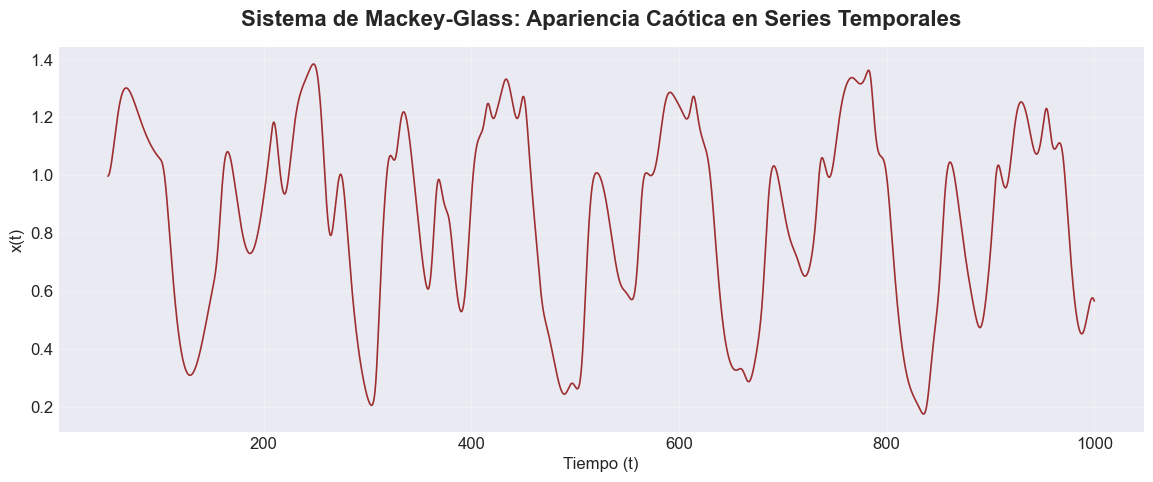

In [7]:
# 1. ECUACIÓN DIFERENCIAL DE MACKEY-GLASS
def mackey_glass_derivative(x_current, x_delayed, beta, gamma, n):
    production = beta * x_delayed / (1 + x_delayed ** n)
    decay = gamma * x_current
    
    return production - decay

# 2. OBTENER EL VALOR RETARDADO (CON HISTORIAL)
def get_delayed_value(x, i, tau_steps, x0):
    if i > tau_steps:
        return x[i - tau_steps]
    else:
        return x0

# 3. SIMULACIÓN UTILIZANDO EL MÉTODO DE EULER
def simulate_mackey_glass(tau, beta, gamma, n, x0 = 0.5, total_steps = 10000, time_step = 0.1):
    # Crear vector de tiempo
    t = np.arange(0, total_steps * time_step, time_step)
    x = np.zeros_like(t)       # ceros en la msima estructura que t

    # Número de pasos (en tiempo) correspondientes al retardo τ
    tau_steps = int(tau / time_step)

    # Bucle de integración
    for i in range(len(t)):
        if i == 0:
            x[i] = x0
        else:
            # Obtener valor retardado
            x_delayed = get_delayed_value(x, i, tau_steps, x0)

            # Calcular derivada
            dxdt = mackey_glass_derivative(x[i - 1], x_delayed, beta, gamma, n)

            # Euler
            x[i] = x[i - 1] + time_step * dxdt

    return t, x

# 4. VISUALIZAR LA SERIE (ELIMINANDO TRANSIENTES)
def plot_mackey_glass(t, x, tau, beta, gamma, n, start_idx):
    plt.figure(figsize=(14, 5))
    plt.style.use('seaborn-v0_8-darkgrid')
    
    # Configuración del gráfico
    plt.title('Sistema de Mackey-Glass: Apariencia Caótica en Series Temporales', 
          fontsize=16, fontweight='bold', pad=25)

    t_plot = t[start_idx:]
    x_plot = x[start_idx:]

    plt.plot(t_plot, x_plot, color='darkred', linewidth=1.2, alpha=0.8)
    plt.title('Sistema de Mackey-Glass: Apariencia caótica en series temporales',
              fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Tiempo (t)', fontsize=12)
    plt.ylabel('x(t)', fontsize=12)
    plt.grid(True, alpha=0.3)

    plt.show()


# Parámetros para régimen caótico
BETA = 0.2
GAMMA = 0.1
N = 10
TAU = 50      # > 16.8 → caos
X0 = 0.5

TOTAL_STEPS = 10000
TIME_STEPS = 0.1

print("Simulando sistema de Mackey-Glass...")
print(f"τ = {TAU} (caótico) | β = {BETA} | γ = {GAMMA} | n = {N}\n")

# Simulación
t_mg, serie_mg = simulate_mackey_glass(TAU, BETA, GAMMA, N, X0, TOTAL_STEPS, TIME_STEPS)

# Visualización
plot_mackey_glass(t_mg, serie_mg, tau=TAU, beta=BETA, gamma=GAMMA, n=N, start_idx=500)


#### Aplicaciones Médicas Reales

Los sistemas tipo Mackey-Glass pueden modelar sistemas como:

* La **hematopoyesis** (producción de células sanguíneas) $\rightarrow$ Leucemia: desregulación del sistema.
* La **variabilidad del ritmo cardíaco (HRV)** $\rightarrow$ HRV normal: caótico (¡sano!). HRV regular: enfermedad (pérdida de complejidad).
* La ocurrencia de crisis en **epilepsia** $\rightarrow$ Transición súbita a sincronización patológica.

**Contradicción médica:**

> En sistemas fisiológicos, **complejidad = salud**, **regularidad = enfermedad**.

(Lo opuesto a ingeniería, donde regularidad = funcionamiento correcto)

---

### El Mapa Logístico: El sistema caótico más simple 

El mapa logístico ocupa exactamente el mismo tipo de posición que los sistemas de Lorenz y Mackey-Glass, pero con un alcance todavía más transversal. Fue introducido en biología poblacional (crecimiento con capacidad de carga y generaciones discretas) y formalizado dinámicamente por Robert May. En ese contexto era un modelo biológico legítimo, no un ejemplo abstracto. Mostraba que incluso modelos poblacionales muy simples podían generar oscilaciones y caos.

El sistema se describe  mediante una **sola ecuación** en tiempo discreto con **un solo parámetro**:

$$x_{t+1} = r \, x_t (1 - x_t)$$

donde $x_t \in [0, 1]$ representa una población normalizada en el año $t$ (o generación, o paso de tiempo) y $r > 0$ es la tasa de crecimiento. En palabras:

> La población del próximo año es la población actual, multiplicada por su tasa de reproducción, pero limitada por cuánto espacio queda disponible en el ecosistema.

Esta ecuación captura el ciclo eterno entre abundancia y escasez que caracteriza a las poblaciones en ecosistemas con recursos limitados.

En el siguiente ejemplo, modelamos el sistema para valores diferentes de $r$.

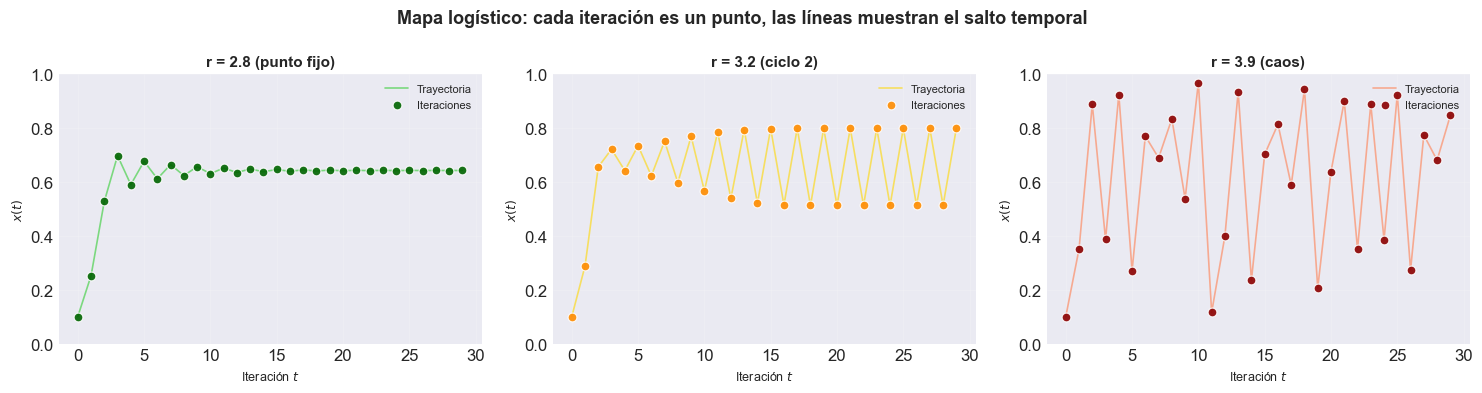

In [8]:
# ============================================================================
# SERIES TEMPORALES DEL MAPA LOGÍSTICO: VALORES DE X(T)
# ============================================================================

def logistic_map_step(x, r):
    return r * x * (1 - x)

# Parámetros
r_values = [2.8, 3.2, 3.9]
labels = [
    "r = 2.8 (punto fijo)",
    "r = 3.2 (ciclo 2)",
    "r = 3.9 (caos)"
]
point_colors = ['darkgreen', 'darkorange', 'darkred']
line_colors = ['limegreen', 'gold', 'coral']

n_iter = 30    
x0 = 0.1

plt.figure(figsize=(15, 4))

for idx, r in enumerate(r_values):
    x = x0
    iterations = np.arange(n_iter)
    trajectory = []
    
    # Generar trayectoria
    for _ in range(n_iter):
        trajectory.append(x)
        x = logistic_map_step(x, r)
    
    # Subgráfica
    plt.subplot(1, 3, idx + 1)
    
    # 1. Dibujar líneas de conexión (entre puntos)
    plt.plot(iterations, trajectory, color=line_colors[idx], 
             linewidth=1.2, alpha=0.6, linestyle='-', 
             label='Trayectoria', zorder=1)
    
    # 2. Dibujar puntos encima
    plt.scatter(iterations, trajectory, color=point_colors[idx], 
                s=40, alpha=0.9, edgecolors='white', linewidth=0.8,
                label='Iteraciones', zorder=2)
    
    plt.title(labels[idx], fontsize=11, fontweight='bold')
    plt.xlabel("Iteración $t$", fontsize=9)
    plt.ylabel("$x(t)$", fontsize=9)
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.15)
    plt.legend(loc='upper right', fontsize=8)

plt.suptitle(
    "Mapa logístico: cada iteración es un punto, las líneas muestran el salto temporal",
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

Estas gráficas muestran el comportamiento del sistema en función del tiempo. Observemos que la dinámica cambia drásticamente para los tres valores de $r$ mostrados, dadas las mismas condiciones iniciales (y ya superado el transitorio), ¿Qué pasa para otros valores de $r$? 

Para analizar ese comportamiento "raro" construímos un **diagrama de bifurcación**: Para miles de valores de $r \in [2.5, 4.0]$ (para este sistema), graficamos todos los valores de $x$ que visita el sistema después del transitorio. Cada columna vertical sobre un valor de $r$
es el atractor de ese parámetro.

DIAGRAMA DE BIFURCACIÓN DEL MAPA LOGÍSTICO
Explorando r ∈ [2.5, 4.0] con 5000 puntos
Transitorio descartado: 1000 iteraciones
Puntos capturados por r: 100



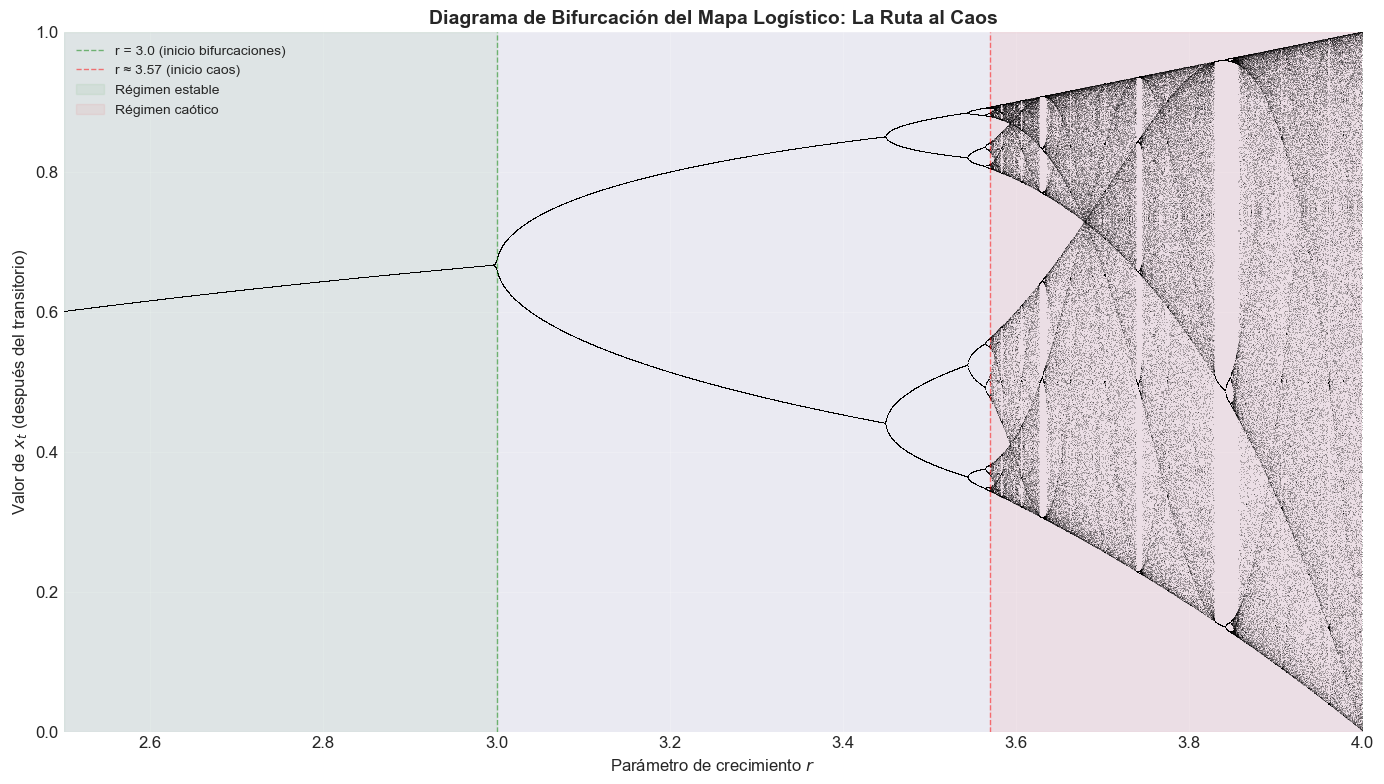

In [9]:
# 1. MAPA LOGÍSTICO
def logistic_map_step(x, r):
    return r * x * (1 - x)

# 2. SIMULACIÓN
def simulate_bifurcation(r_values, x0=1e-5, N=1000, M=100):
    # Inicializar un array con la condición inicial para todos los r
    x = x0 * np.ones_like(r_values)
    
    # Descartar transitorios
    for _ in range(N):
        x = logistic_map_step(x, r_values)
    
    # Almacenar puntos del atractor
    points = []
    for _ in range(M):
        x = logistic_map_step(x, r_values)
        points.append(x.copy())  # copia para evitar referencias
    
    return np.array(points)

# 3. VISUALIZACIÓN 
def plot_bifurcation_diagram(r_values, points):
    plt.figure(figsize=(14, 8))
    # Transponer points para que cada columna sea un r y cada fila una iteración
    plt.plot(r_values, points.T, ',k', alpha=0.25, markersize=0.5)
    
    # Anotaciones visuales
    plt.axvline(x=3.0, color='green', linestyle='--', alpha=0.5, linewidth=1,
                label='r = 3.0 (inicio bifurcaciones)')
    plt.axvline(x=3.57, color='red', linestyle='--', alpha=0.5, linewidth=1,
                label='r ≈ 3.57 (inicio caos)')
    plt.axvspan(2.5, 3.0, alpha=0.05, color='green', label='Régimen estable')
    plt.axvspan(3.57, 4.0, alpha=0.05, color='red', label='Régimen caótico')
    
    plt.title("Diagrama de Bifurcación del Mapa Logístico: La Ruta al Caos",
              fontsize=14, fontweight='bold')
    plt.xlabel("Parámetro de crecimiento $r$", fontsize=12)
    plt.ylabel("Valor de $x_t$ (después del transitorio)", fontsize=12)
    plt.xlim(2.5, 4.0)
    plt.ylim(0, 1)
    plt.legend(loc='upper left', fontsize=10)
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()


# Parámetros de la simulación
R_MIN, R_MAX = 2.5, 4.0
N_RESOLUTION = 5000          # número de valores de r
N_TRANSIENT = 1000           # iteraciones a descartar
M_ATTRACTOR = 100           # puntos a guardar por cada r
X_INITIAL = 1e-5           # condición inicial (cerca de cero)

print("="*70)
print("DIAGRAMA DE BIFURCACIÓN DEL MAPA LOGÍSTICO")
print(f"Explorando r ∈ [{R_MIN}, {R_MAX}] con {N_RESOLUTION} puntos")
print(f"Transitorio descartado: {N_TRANSIENT} iteraciones")
print(f"Puntos capturados por r: {M_ATTRACTOR}")
print("="*70 + "\n")

# Generar valores de r
R_VALUES = np.linspace(R_MIN, R_MAX, N_RESOLUTION)

# Simular
points = simulate_bifurcation(R_VALUES, X_INITIAL, N_TRANSIENT, M_ATTRACTOR)

# Graficar
plot_bifurcation_diagram(R_VALUES, points)



El mapa logístico es el ejemplo paradigmático de cómo **complejidad ≠ complicación**:

| Característica | Detalle |
|:--------------|:--------|
| **Ecuación** | Una línea de código |
| **Dimensión** | 1D (una sola variable) |
| **Parámetros** | Uno solo ($r$) |
| **Comportamiento** | Desde estabilidad hasta caos completo |



Cada **columna vertical** en la gráfica (cada linea vertical) representa el comportamiento del sistema para un valor específico de $r$:

- **Un solo punto**: El sistema converge a un valor fijo (equilibrio estable)
- **Dos puntos**: El sistema oscila entre dos valores (período 2)
- **Múltiples puntos discretos**: Oscilaciones periódicas (período 4, 8, 16...)
- **Banda continua**: Comportamiento caótico (valores impredecibles)

La **Zona Verde ($r < 3$)** es una región de **régimen estable**:
- El sistema converge a un **punto fijo** único
- Predecible y estable
- Ej: $r = 2.8 \rightarrow x_t \to 0.643$ para cualquier condición inicial

La **Zona de Transición** ($3 < r < 3.57$) es una región con **múltiples bifurcaciones**
- **Primera bifurcación ($r \approx 3$)**: Aparece oscilación de período 2
- **Duplicaciones sucesivas**: Período 4 → 8 → 16 → 32...
- Cada bifurcación ocurre **más rápido** que la anterior

La **Zona Roja** ($r > 3.57$) es el **régimen caótico**
- El eje vertical se "llena" → comportamiento **aperiódico**
- Sensibilidad extrema a condiciones iniciales
- **Ventanas de orden**: Islas periódicas dentro del caos (ej: período 3 en $r \approx 3.83$)
- **Estructura fractal**: Zoom en cualquier región revela el mismo patrón (¡globalmente, el sistema también muestra ese comportamiento fractal!)

A partir del **Punto Crítico ($r = 4$)) Caos Completo**
- Distribución **uniforme** en $[0, 1]$
- Máxima entropía
- Comportamiento totalmente impredecible a largo plazo

> Lo notable: dentro del caos aparecen "ventanas de orden" (líneas blancas verticales), donde momentáneamente resurgen ciclos periódicos—evidencia de que orden y caos no son excluyentes, sino que coexisten en una estructura fractal. 

Esta misma estructura matemática aparece en modelos de poblaciones biológicas, tasas de interés y dinámicas neuronales.


#### Por qué los métodos tradicionales fallan aquí

| Método | Por Qué Falla |
|:-------|:--------------|
| **Regresión lineal** | Asume relación suave $y = mx + b$. El diagrama muestra discontinuidades |
| **ARIMA** | Asume estacionariedad y estructura lineal. El caos es no-estacionario y no-lineal |
| **Análisis de Fourier** | Busca periodicidad. El caos es aperiódico (no tiene frecuencias fundamentales) |
| **Predicción punto a punto** | Ignora la estructura del atractor. Pequeños errores se amplifican exponencialmente |

---


## 4. SISTEMAS REALES COMPLEJOS

### Bonus: Modelos ARIMA (AutoRegressive Integrated Moving Average)

Los modelos **ARIMA** son el estándar clásico para el análisis de series de tiempo lineales. Aunque en este curso nos enfocamos en dinámica no lineal y sistemas complejos, ARIMA forma parte del bagaje mínimo que todo científico de datos debería conocer.

Un modelo ARIMA se denota como:

$
\text{ARIMA}(p, d, q)
$

donde cada componente tiene un significado específico.

<ul>
    <li><b>Componente AR</b> (<em>AutoRegressive</em>). El término $AR(p)$ modela la variable como una combinación lineal de sus 
        propios valores pasados<br>
        ($y_t = \phi_1 y_{t-1} + \phi_2 y_{t-2} + \dots + \phi_p y_{t-p} + \varepsilon_t$), <br> y es un 
        método de análisis de series de tiempo por sí msimo.
        <br><br>
    </li>
    <li><b>Componente I</b> (<em>Integrated</em>). El término $I(d)$, el término integral, no es un modelo en sí, sino una 
        <b>operación de diferenciación</b> para inducir estacionariedad. En la siguiente imagen, por ejemplo, aplicamos una doble 
        diferenciación sobre una serie de tiempo para eliminar la tendencia cuadrática:<br>
        <p align="center">
          <img src="images/timeseries_ doble_diferencia.png" width="80%">
        </p>       
    </li>
    <li><b>Componente MA</b> (<em>Moving Average</em>). Este término modela la variable como una combinación lineal de <b>errores 
        pasados</b>: <br>
        $y_t = \varepsilon_t + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2} + \dots + \theta_q \varepsilon_{t-q}$    
    </li>
</ul>

El modelo completo combina las 3 componentes:

1. Diferenciación de la serie \(d\) veces → estacionariedad  
2. Modelado AR(p) sobre la serie diferenciada  
3. Modelado MA(q) sobre los residuos

Apliquemos el método ARIMA a una serie de tiempo generada por un sistema caótico, probemos con la serie de Mackey-Glass. 

RMSE: 0.3528459509761005


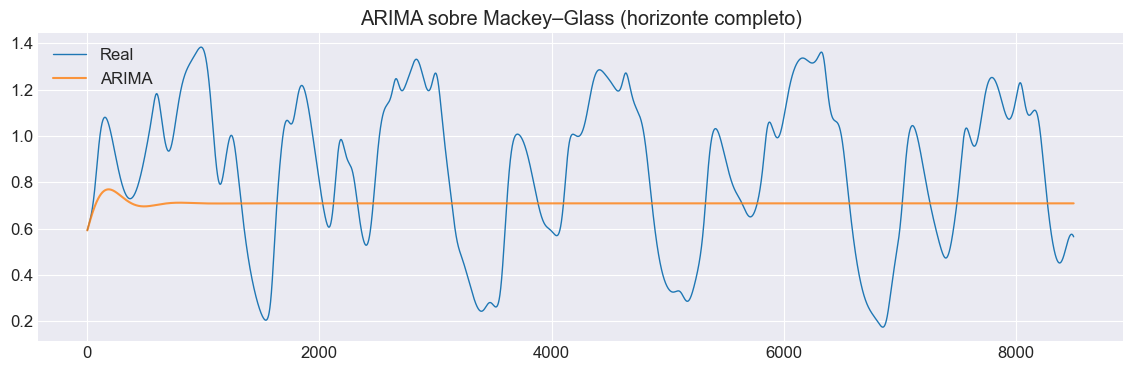

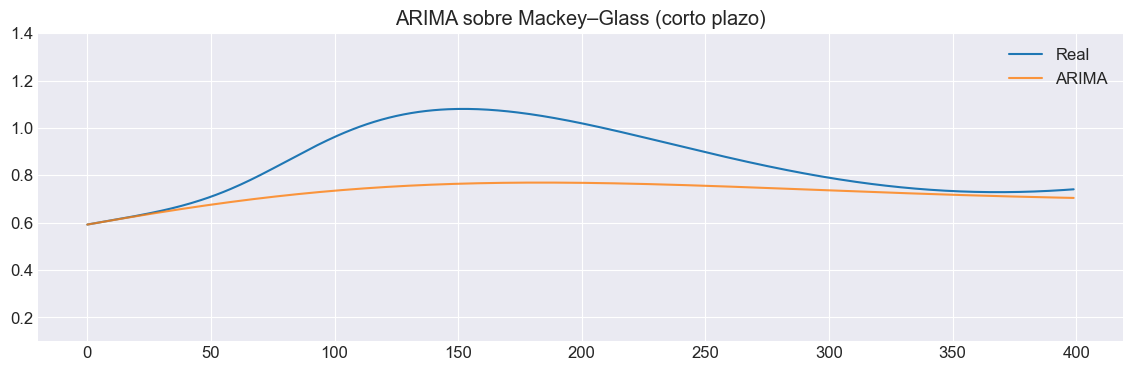

In [10]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# Usar serie ya generada
start_idx = 0
series = serie_mg[start_idx:]

# Escalado (mejora estabilidad numérica)
scaler = StandardScaler()
series_scaled = scaler.fit_transform(series.reshape(-1, 1)).flatten()

# Split train/test
train_size = 1500
train, test = series_scaled[:train_size], series_scaled[train_size:]

# ARIMA más estable para señal caótica
model = ARIMA(train, order=(3,1,0), enforce_stationarity=False, enforce_invertibility=False)
model_fit = model.fit(method_kwargs={"warn_convergence": False})

# Predicción
forecast = model_fit.forecast(steps=len(test))

# Volver a escala original para interpretar RMSE
forecast_inv = scaler.inverse_transform(forecast.reshape(-1, 1)).flatten()
test_inv = scaler.inverse_transform(test.reshape(-1, 1)).flatten()

rmse = np.sqrt(mean_squared_error(test_inv, forecast_inv))
print("RMSE:", rmse)

# ----------- GRÁFICA 1: HORIZONTE COMPLETO -----------
plt.figure(figsize=(14, 4))
plt.plot(test_inv, label="Real", linewidth=1)
plt.plot(forecast_inv, label="ARIMA", alpha=0.8)
plt.title("ARIMA sobre Mackey–Glass (horizonte completo)")
plt.legend()
plt.show()

# ----------- GRÁFICA 2: ZOOM CORTO PLAZO -----------
zoom_steps = 400

plt.figure(figsize=(14, 4))
plt.plot(test_inv[:zoom_steps], label="Real", linewidth=1.5)
plt.plot(forecast_inv[:zoom_steps], label="ARIMA", alpha=0.8)
plt.ylim(0.1, 1.4) 
plt.title("ARIMA sobre Mackey–Glass (corto plazo)")
plt.legend()
plt.show()


Resultados esperados:

<ol>
    <li><b>Buen ajuste local, mala predicción global</b>.<br>
        ARIMA suele capturar la tendencia local inmediata, pero rápidamente pierde fase.<br><br>
    </li>
    <li><b>Divergencia exponencial del pronóstico</b>.<br>
        Debido a la sensibilidad a condiciones iniciales del sistema caótico.<br><br>
    </li>
    <li><b>Error creciente con el horizonte</b>.<br>
        A corto plazo puede parecer “razonable”; a mediano plazo se vuelve esencialmente ruido.<br><br>
    </li>
    <li><b>Modelo lineal sobre dinámica no lineal</b>.<br>
        ARIMA solo captura correlaciones lineales de bajo orden, mientras que Mackey–Glass tiene:
        <ul>
            <li>memoria retardada</li>
            <li>no linealidad racional</li>
            <li>atractor extraño</li>
            </ul>
            </li>    
</ol>

#### ¿Por qué fallan los métodos tradicionales (como ARIMA, en este ejemplo)?

Los métodos tradicionales no fallan por incompetencia, sino porque fueron diseñados para otro mundo.
> ARIMA no “falla” por ser un mal modelo; falla porque estamos pidiéndole que describa una dinámica que viola sus supuestos fundamentales.

Los supuestos de los métodos tradicionales no se cumplen en sistemas complejos:
| Supuesto | Realidad en Sistemas Complejos |
| :--- | :--- |
| **Linealidad** | Interacciones no lineales dominantes |
| **Gaussianidad** | Colas pesadas, multimodalidad |
| **Estacionariedad** | Cambios de régimen, no estacionariedad estructural |
| **Baja sensibilidad** | Sensibilidad exponencial a inicialización (caos) |
| **Ruido aditivo** | Ruido multiplicativo, endógeno |

---

## 5. Caos, Ruido y Azar

En el análisis de series de tiempo es común observar señales que *parecen* irregulares. Sin embargo, esa irregularidad puede tener orígenes muy distintos:

<p align="center">
    <img src="images/timeseries_noise_like.png" width="80%">
</p>       

¿Cómo podemos distinguir entre caos determinista, procesos estocásticos, y ruido puro cuando todos se ven similares?

### Caos determinista
El **caos** proviene de sistemas **deterministas no lineales** que exhiben comportamiento aparentemente aleatorio. Sus características distintivas son:

| Propiedad | Descripción |
|:----------|:------------|
| **Origen** | Ecuaciones deterministas exactas (ej: Lorenz, mapa logístico) |
| **Sensibilidad a C.I.** | Condiciones iniciales microscópicamente diferentes → trayectorias radicalmente distintas |
| **Atractor extraño** | Dimensión fractal **finita** (ej: 2.06 para Lorenz) |
| **Estructura geométrica** | Organización clara en el espacio de fases reconstruido |
| **Predictibilidad** | Corto plazo: predecible. Largo plazo: impredecible (horizonte finito) |

Aunque la señal *parece* ruidosa, aleatoria o sucia, su origen es **completamente determinista**. Existe una *máquina* subyacente que genera la complejidad.


### Aleatoriedad (procesos estocásticos)
La **aleatoriedad** describe procesos que carecen de una descripción determinista simple, pero que exhiben **estructura probabilística reproducible**. Sus características más importantes son:

| Propiedad | Descripción |
|:----------|:------------|
| **Origen** | Procesos estocásticos con reglas probabilísticas (ej: ARMA, GARCH, caminatas aleatorias) |
| **Autocorrelación** | Puede tener correlaciones lineales y no-lineales |
| **Predictibilidad** | Parcialmente predecible en términos de **distribuciones**, no de valores exactos |
| **Dimensión** | No existe atractor determinista de baja dimensión |
| **Estructura** | Patrones estadísticos (colas pesadas, memoria) |

Los movimientos de precios de acciones, divisas y criptomonedas, por ejemplo, suelen ser modelados como caminatas aleatorias. La Hipótesis del Mercado Eficiente (HME), por ejemplo, sostiene que los precios no son determinados por comportamientos previos y solo reaccionan a nueva información impredecible. 

Desde una perspectiva operativa, la aleatoriedad es más una **hipótesis de trabajo falsable** que una propiedad demostrable del mundo:

> *"Asumimos aleatoriedad hasta que encontramos estructura determinista."*

No podemos *probar* que algo es aleatorio, solo podemos *fallar en encontrar* patrones deterministas con las herramientas disponibles.


### Ruido 
El **ruido** es una perturbación estocástica que **no contiene estructura útil** para la predicción. Las características distintivas del ruido son:

| Propiedad | Descripción |
|:----------|:------------|
| **Origen** | Agregación de muchas fuentes independientes pequeñas |
| **Ejemplo prototípico** | Ruido blanco gaussiano: $\epsilon_t \sim \mathcal{N}(0, \sigma^2)$ i.i.d. |
| **Media** | Constante (típicamente cero) |
| **Autocorrelación** | para todos los rezagos |
| **Predictibilidad** | **Cero**. Impredecible incluso con conocimiento completo del pasado |
| **Información** | No contiene información sobre valores futuros |

El ruido blanco, el caso más emblemático del ruido, **carece de dinámica interna observable** en la variable medida. Cada observación es completamente independiente de las demás. Algunos ejemplos cotidianos son:

- Ruido térmico en circuitos electrónicos
- Errores de medición en instrumentos
- Residuos de modelos bien ajustados

El **ruido blanco** es un caso idealizado que raramente se observa en sistemas reales. En la práctica, encontramos ruidos con **estructura temporal** que afecta cómo modelamos y predecimos series temporales.

Los diferentes tipos de ruido se clasifican según su **espectro de potencia** (cómo se distribuye la energía entre frecuencias). La analogía con colores viene de la luz: el ruido blanco tiene todas las frecuencias por igual, como la luz blanca.

| Tipo de Ruido | Espectro de Potencia | Exponente β | Autocorrelación | Aplicaciones Típicas |
|:-------------|:--------------------|:-----------|:---------------|:---------------------|
| **Blanco** | Plano (constante) | β = 0 | Ninguna (ACF ≈ 0) | Errores de medición, residuos ideales |
| **Rosa (1/f)** | Inversamente proporcional a f | β = 1 | Decae lentamente | Música, fisiología, finanzas |
| **Browniano (rojo)** | Proporcional a 1/f² | β = 2 | Persistente (caminata aleatoria) | Difusión, movimiento Browniano |
| **Azul** | Proporcional a f | β = -1 | Anti-persistente | Procesos de alta frecuencia |
| **Violeta** | Proporcional a f² | β = -2 | Fuertemente anti-persistente | Derivadas de procesos |

donde $\beta$ es el **exponente espectral**.

El "color" del ruido puede interpretarse como **evidencia de que no hemos separado adecuadamente la componente determinista de la componente estocástica**. Toda serie temporal observada puede descomponerse (conceptualmente) como:

$$x_t = \underbrace{f(x_{t-1}, x_{t-2}, ..., x_{t-p})}_{\text{Componente determinista}} + \underbrace{\epsilon_t}_{\text{Componente estocástica}}$$

**El objetivo del modelado:** Encontrar $f(\cdot)$ tal que $\epsilon_t$ sea **ruido blanco**.

---

## 6. La necesidad de metaheurísticas: Un argumento estructural

Las características fundamentales de los sistemas dinámicos explorados aquí, como la no linealidad, sensibilidad a condiciones iniciales, multimodalidad o emergencia espontánea de patrones, no son curiosidades matemáticas ni casos extremos; son la **norma en los datos del mundo real**. Y ante esa realidad, las metaheurísticas surgen, no como una opción holgazana, tramposa y poco seria, sino como la única herramienta útil en muchos casos.

Las características que observamos en sistemas complejos corresponden exactamente a las capacidades que distinguen a las metaheurísticas:

| Característica del sistema | Desafío que plantea | Respuesta de metaheurísticas |
|:---------------------------|:--------------------|:-----------------------------|
| **No linealidad** | Los gradientes no apuntan al óptimo | Búsqueda libre de gradientes |
| **Multimodalidad** | Múltiples óptimos locales | Exploración global + poblaciones diversas |
| **Rugosidad** | Discontinuidades, no diferenciabilidad | Operadores robustos (cruce, mutación, perturbación) |
| **Dimensionalidad alta** | Explosión combinatoria | Muestreo inteligente del espacio |
| **Sensibilidad a parámetros** | Bifurcaciones, dependencia extrema | Exploración adaptativa, múltiples inicializaciones |
| **Evaluación costosa** | No podemos evaluar exhaustivamente | Búsqueda guiada, balance exploración-explotación |

<br>

Los sistemas caóticos que estudiamos (Lorenz, Mackey-Glass, mapa logístico) no son solo ejemplos teóricos; son **laboratorios controlados** donde:

1. **Conocemos la verdad fundamental**: Las ecuaciones exactas que generan los datos
2. **Controlamos la complejidad**: Modulamos el caos ajustando parámetros ($r$ en el mapa logístico, $\rho$ en Lorenz, $\tau$ en Mackey-Glass)
3. **Validamos métodos rigurosamente**: Si una metaheurística no puede recuperar $\theta$ conocida, cómo confiar en que no fallará en datos reales
4. **Experimentamos sin costo**: Generamos millones de trayectorias sintéticas a voluntad

> Si un método no puede calibrar Lorenz (donde conocemos la respuesta exacta) ¿Cómo confiamos en él para series financieras, climáticas o epidemiológicas (donde nunca sabremos la respuesta)?

Estos sistemas de "juguete" aparentemente simples **son el estándar ideal para validar herramientas** antes de aplicarlas al caos del mundo real.

> Hoy se usan como bancos de prueba en aprendizaje automático, pero en sus disciplinas de origen siguen siendo modelos canónicos para entender mecanismos dinámicos fundamentales (caos y retardos). No son herramientas operativas, pero sí referentes teóricos activos.


<div style="
  background: #fdf8e3;
  border-left: 6px solid #d39e00;
  padding: 20px 25px;
  margin: 30px 0;
  border-radius: 8px;
  font-style: italic;
  color: #5a4a00;
  box-shadow: 0 4px 8px rgba(0,0,0,0.05);
">
  <p style="margin: 0; font-size: 16px; line-height: 1.6;">
    “All models are wrong, but some are useful.”
  </p>
  <p style="margin: 10px 0 0 0; text-align: right; font-weight: bold;">
    — George E.P. Box
  </p>
</div>



<div style="border: 2px solid #24398A; border-radius: 15px; padding: 20px; background-color: #fcfcfc;">
    <h3 style="color: #24398A; margin-top: 0;">Conclusiones: Del caos a la herramienta</h3>
    <p style="font-size: 15px; line-height: 1.6;">
        Esta lección ha trazado un camino desde los fundamentos teóricos de los sistemas complejos hasta la justificación formal 
        de las metaheurísticas como herramientas esenciales en ciencia de datos.
    </p>
    <ul style="font-size: 14px; color: #333;">
        <li><b>El mensaje central:</b> La complejidad no es excepción, es regla. Los sistemas que estudiamos en esta lección—
            el Juego de la Vida, el atractor de Lorenz, la ecuación de Mackey-Glass, el mapa logístico—no son curiosidades 
            matemáticas. Son <b>arquetipos de comportamiento</b> que aparecen consistentemente en muy diversas áreas del mundo
            real. 
        </li>
        <li><b>Las series de tiempo como lenguaje universal:</b> Las series de tiempo no son solo secuencias de números, son
            el <b>lenguaje natural de los sistemas dinámicos</b>. Una serie temporal $\{x_t\}$ es la proyección observable de 
            un sistema complejo de alta dimensión operando en segundo plano.</li>
        <li><b>La necesidad estructural de las metaheurísticas:</b> Las metaheurísticas no son "trucos" ni métodos ad-hoc: son 
            la <b>respuesta matemáticamente coherente</b> a la realidad de los datos del mundo.</li>
        <li><b>Humildad epistémica y rigor metodológico:</b> Los métodos clásicos **asumen** que el mundo es simple (lineal, 
            estacionario, convexo) y fallan silenciosamente cuando esos supuestos se violan. Las metaheurísticas parten de una 
            premisa más humilde: <b>el mundo es complejo</b>, y nuestro trabajo es navegar esa complejidad lo mejor posible, sin 
            ilusiones de soluciones analíticas perfectas.</li>
    </ul>

</div>
